# Reversible Map Point Encryption

## What Does This Notebook Do?

This notebook demonstrates a technique for **encrypting geographic coordinates** (latitude/longitude points) so that:

- A database or display layer sees only **scrambled, imprecise** locations — protecting user privacy
- Authorised systems with the correct secret key can recover the **exact** original coordinates
- The scheme is fully **reversible** — no data loss when you have the key

---

## The Plain-Language Story

Think of a city covered by a grid of **250-metre square tiles** — like a chessboard laid over a map. Every GPS point falls inside one tile. The system processes each point in four steps:

| Step | What happens | Everyday analogy |
|------|--------------|------------------|
| **1. Snap** | Round the point to the nearest grid tile | Sorting letters into numbered P.O. boxes |
| **2. Shuffle** | Rearrange the tiles using a secret key | Shuffling a deck of cards only you can reverse |
| **3. Lock** | Encrypt the exact sub-tile position in a sealed envelope | Sealing a precise address inside a combination lockbox |
| **4. Wobble** | Show the shuffled tile with a small per-record smudge | Deliberately blurring a dot on a map |

Only someone with the correct **key** can reverse steps 2 and 3 to recover the true location.

---

## Glossary of Key Terms

| Term | Plain meaning |
|------|---------------|
| **Latitude / Longitude** | Standard GPS coordinates — degrees North/South and East/West |
| **Web Mercator (EPSG:3857)** | A standard projection converting lat/lon into flat x/y distances in metres, used by Google Maps and OpenStreetMap |
| **Grid cell / tile** | One square in the chessboard overlay; here each tile is 250 m x 250 m |
| **PRP (Pseudorandom Permutation)** | A reversible, key-driven shuffle: same input always maps to the same output, but the mapping looks random without the key |
| **Feistel cipher** | A classic way to build a PRP by alternately mixing two halves of a value across many rounds; reversible by running the rounds backwards |
| **AEAD** | Authenticated Encryption with Associated Data — simultaneously *hides* data and *detects any tampering* |
| **Nonce** | A 'number used once' — a fresh random value generated per encryption. Ensures two identical locations encrypt to different ciphertexts. Safe to store publicly |
| **Associated Data (AD)** | Metadata that is *authenticated* but not encrypted — binds a ciphertext to its correct context so it cannot be moved |
| **Tweak** | Extra input to the PRP that customises the shuffle per record without needing a separate key |
| **Key Derivation** | Generating several independent subkeys from one master secret so each component uses its own isolated key |
| **Rejection sampling** | A bias-elimination technique: draw random values until one falls in a provably fair range, discard any that do not |
| **Round-trip** | Encoding then decoding should return the exact original value — verified in the demo below |

> **Version 3 note**: This notebook restores the previously omitted Sections 7 and 8 from the earlier notebook, updated to match the improved v2 API and record format.

In [1]:
'''Reversible Map Point Encryption — Improved Implementation

Security improvements over the original version:
  1. Unbiased PRF output via rejection sampling  (eliminates modular skew)
  2. Length-prefixed Associated Data             (prevents boundary-shift ambiguity)
  3. Per-record jitter derived from nonce        (prevents co-location fingerprinting)
  4. Record ID bound into tweak                  (prevents record-substitution attacks)
  5. Single master key with HKDF-style KDF       (cleaner key management)
  6. Scheme version field in every record        (enables future migration)
  7. Fallback HMAC uses length-prefixed inputs   (consistent ambiguity fix)
'''

import math
import struct
import secrets
import hashlib
import hmac
from dataclasses import dataclass
from typing import Tuple, Optional, Dict, Any

import numpy as np
import matplotlib.pyplot as plt

print('Dependencies loaded successfully.')

Dependencies loaded successfully.


---

## Section 1 — Coordinate Projection

### Why not work directly in latitude/longitude?

Latitude and longitude are **angular** measurements. One degree of longitude near the equator spans about 111 km, but near the poles it shrinks to nearly zero. If we built our grid directly in degrees, tiles at high latitudes would represent far more actual ground area than tiles near the equator — making the privacy guarantee inconsistent.

**Web Mercator** (EPSG:3857 — the projection used by Google Maps and OpenStreetMap) converts lat/lon into **metres** on a flat plane. A 250 m tile now means the same ground extent everywhere on the map, at least within mid-latitudes.

> **Trade-off**: Web Mercator distorts areas near the poles. A 250 m tile in Oslo covers more real ground than one in Miami. For polar regions, a local UTM projection gives more accurate results. Web Mercator is the practical standard for most applications.

### How the maths works

The Mercator projection wraps the globe onto a cylinder:
- **Longitude** maps linearly to x-metres: `x = R * lon_radians`
- **Latitude** uses a logarithmic formula to preserve local shapes (angles are correct, but areas stretch toward the poles)

The projection is **exact and invertible** — we can recover the original lat/lon from (x, y) with no approximation.

In [2]:
# Earth's equatorial radius in metres (WGS84 standard, used by Web Mercator)
R_EARTH = 6_378_137.0


def clamp_lat(lat_deg: float) -> float:
    '''
    Web Mercator is undefined at the exact poles (y approaches infinity).
    Clamp to the conventional limit of +-85.05 degrees.
    '''
    return max(-85.05112878, min(85.05112878, lat_deg))


def project_3857(lat_deg: float, lon_deg: float) -> Tuple[float, float]:
    '''
    Convert (latitude, longitude) in degrees to Web Mercator (x, y) in metres.
    x increases eastward; y increases northward.
    At the equator: 1 metre ~ 9e-6 degrees of latitude or longitude.
    '''
    lat = math.radians(clamp_lat(lat_deg))
    lon = math.radians(lon_deg)
    x = R_EARTH * lon
    y = R_EARTH * math.log(math.tan(math.pi / 4.0 + lat / 2.0))
    return x, y


def unproject_3857(x: float, y: float) -> Tuple[float, float]:
    '''
    Inverse of project_3857: Web Mercator (x, y) in metres to (lat, lon) in degrees.
    This is an exact inverse with no numerical approximation.
    '''
    lon_deg = math.degrees(x / R_EARTH)
    lat_deg = math.degrees(2.0 * math.atan(math.exp(y / R_EARTH)) - math.pi / 2.0)
    return lat_deg, lon_deg


# Sanity check: project and unproject Times Square; result must match exactly.
_lat0, _lon0 = 40.758, -73.985
_x, _y = project_3857(_lat0, _lon0)
_lat1, _lon1 = unproject_3857(_x, _y)
assert abs(_lat1 - _lat0) < 1e-10 and abs(_lon1 - _lon0) < 1e-10, 'Projection round-trip failed'
print(f'Times Square in Web Mercator: x = {_x:,.1f} m,  y = {_y:,.1f} m')
print('Projection round-trip: OK')

Times Square in Web Mercator: x = -8,235,972.5 m,  y = 4,976,712.0 m
Projection round-trip: OK


---

## Section 2 — Grid Snapping and the Shuffle (PRP)

### Step 1: Snapping to the grid

Once a point is in metres, we divide by the tile size and round to the nearest integer to get a **grid cell index** `(qx, qy)`. The remainder — the exact position within that tile — is saved as the *residual* `(rx, ry)`:

```
qx = round(x / 250)       # which column of the chessboard?
qy = round(y / 250)       # which row?
rx = x - qx * 250         # sub-tile offset in x, always in (-125, +125) m
ry = y - qy * 250         # sub-tile offset in y
```

The residual contains the **full precision** of the original GPS fix. It will be encrypted in Section 3.

### Step 2: Shuffling — the Pseudorandom Permutation (PRP)

A **PRP** maps every grid cell `(qx, qy)` to a unique shuffled cell `(qx', qy')`. It is:
- **Reversible**: given the key, you can always undo the shuffle to get back the original cell
- **Pseudorandom**: without the key, the mapping looks completely random — no pattern is detectable
- **Bounded**: shuffled cells stay within the valid Web Mercator extent, not scattered to infinity

We use a **Feistel structure** — the same building block as DES. Each round mixes one coordinate with a pseudorandom function of the other:

```
for each round r:
    F = PRF(key, tweak, r, right_half)    # pseudorandom value
    left_half = (left_half + F) mod M     # mix left with a function of right
    swap left_half and right_half         # alternate which half is mixed
```

Running in reverse (reversed round order, subtraction instead of addition) exactly recovers the original.

### Why rejection sampling?

A naive `hash(...) % N` has **modular bias**: if `2^256` is not exactly divisible by N, some outputs appear more often than others. Over millions of records this creates a detectable frequency fingerprint.

**Rejection sampling** fixes this: generate a 256-bit hash and check whether it falls below the largest exact multiple of N within `2^256`. If yes, take the remainder — now every output is equally likely. If no (an extremely rare event), try again. Expected additional iterations: less than one in `10^71`.

In [3]:
def _mercator_grid_bounds(bin_size_m: int) -> Tuple[int, int, int, int]:
    '''
    Return (min_qx, max_qx, min_qy, max_qy): the valid range of grid-cell
    indices for the full Web Mercator world extent (+-20,037,508 m in both axes).
    '''
    HALF_WORLD = 20_037_508.342789244   # half Earth circumference in metres
    lo = int(math.floor(-HALF_WORLD / bin_size_m))
    hi = int(math.floor(+HALF_WORLD / bin_size_m))
    return lo, hi, lo, hi


def _prf_upto(key: bytes, data: bytes, modulo: int) -> int:
    '''
    Return an unbiased pseudorandom integer in [0, modulo) using rejection sampling.

    Why rejection sampling?
    A naive `hash(...) % N` is biased when 2^256 is not divisible by N:
    values in [0, 2^256 mod N) appear with probability (floor(2^256/N)+1)/2^256
    instead of the correct 1/N. Over millions of records this is detectable.

    Fix: reject any hash value >= floor(2^256/N)*N and retry with a new counter.
    The probability of rejection per attempt is (2^256 mod N) / 2^256 < N/2^256,
    which for N ~ 161,000 is less than 10^-71. We almost never retry.
    '''
    cutoff = ((1 << 256) // modulo) * modulo   # largest unbiased threshold
    counter = 0
    while True:
        h = hashlib.blake2s(key=key, digest_size=32)
        h.update(data + struct.pack('>I', counter))
        val = int.from_bytes(h.digest(), 'big')
        if val < cutoff:
            return val % modulo
        counter += 1   # in practice, almost never executed


def prp_rect_encrypt(qx: int, qy: int, key: bytes, tweak: bytes,
                     bin_size_m: int, rounds: int = 10) -> Tuple[int, int]:
    '''
    Feistel PRP: reversibly map grid cell (qx, qy) to a shuffled cell (qx', qy').

    Properties:
    - True permutation (bijection) over the full grid: no two inputs share an output
    - Reversible: prp_rect_decrypt with the same key/tweak recovers the original
    - Tweak: a per-record value that customises the shuffle without a separate key

    The grid is square (M = N for Web Mercator at fixed bin_size_m), simplifying
    the alternating-dimension Feistel logic to a single modulus M.
    '''
    min_q, max_q, _, _ = _mercator_grid_bounds(bin_size_m)
    M = max_q - min_q + 1   # total cells per axis
    L  = qx - min_q          # work in [0, M) to avoid negative modular arithmetic
    Rv = qy - min_q

    for r in range(rounds):
        F  = _prf_upto(key, tweak + struct.pack('>II', r, Rv), M)
        L  = (L + F) % M
        L, Rv = Rv, L          # swap: alternate which half is the 'left'

    # If rounds is odd, the final swap put the halves in the wrong positions; undo it.
    if rounds % 2 == 1:
        L, Rv = Rv, L

    return L + min_q, Rv + min_q


def prp_rect_decrypt(qx_p: int, qy_p: int, key: bytes, tweak: bytes,
                     bin_size_m: int, rounds: int = 10) -> Tuple[int, int]:
    '''
    Inverse of prp_rect_encrypt.
    Run the Feistel rounds in reverse order with subtraction instead of addition.
    Must use the identical key, tweak, bin_size_m, and rounds as encryption.
    '''
    min_q, max_q, _, _ = _mercator_grid_bounds(bin_size_m)
    M  = max_q - min_q + 1
    L  = qx_p - min_q
    Rv = qy_p - min_q

    # Undo the post-loop swap correction that was applied during encryption.
    if rounds % 2 == 1:
        L, Rv = Rv, L

    for r in reversed(range(rounds)):
        L, Rv = Rv, L                            # undo the forward swap
        F     = _prf_upto(key, tweak + struct.pack('>II', r, Rv), M)
        L     = (L - F) % M                      # undo the addition

    return L + min_q, Rv + min_q


# Round-trip check
_test_key = hashlib.blake2s(b'test-prp-key', digest_size=32).digest()
_qx_in, _qy_in = 12345, -6789
_tweak = b'round-trip-test'
_qxp, _qyp   = prp_rect_encrypt(_qx_in, _qy_in, _test_key, _tweak, 250)
_qx_out, _qy_out = prp_rect_decrypt(_qxp, _qyp, _test_key, _tweak, 250)
assert (_qx_out, _qy_out) == (_qx_in, _qy_in), 'PRP round-trip failed'
print(f'PRP forward:  ({_qx_in:>7}, {_qy_in:>7})  ->  encrypted ({_qxp:>7}, {_qyp:>7})')
print(f'PRP inverse:  ({_qxp:>7}, {_qyp:>7})  ->  decrypted ({_qx_out:>7}, {_qy_out:>7})')
print('PRP round-trip: OK')

PRP forward:  (  12345,   -6789)  ->  encrypted (  65142,   66153)
PRP inverse:  (  65142,   66153)  ->  decrypted (  12345,   -6789)
PRP round-trip: OK


---

## Section 3 — Encrypting the Residual (AEAD)

After snapping, the **residual** `(rx, ry)` holds the exact GPS position within the tile — the most sensitive piece of data. We seal it with **AEAD** (Authenticated Encryption with Associated Data), which provides two guarantees simultaneously:

| Guarantee | What it means |
|-----------|---------------|
| **Confidentiality** | Nobody without the key can read `(rx, ry)` |
| **Integrity / Authenticity** | Any modification to the ciphertext — even a single bit — is detected; decryption returns failure |

### The nonce

A **nonce** (number used once) is a fresh 12-byte random value generated for every encryption. It ensures that encrypting the same residual in the same tile twice produces *completely different* ciphertexts. The nonce is **not secret** — it is stored openly alongside the ciphertext.

### Associated Data — binding the ciphertext to its context

The **Associated Data (AD)** here is `(qx, qy, tweak)`: the original (pre-shuffle) grid cell plus the record tweak. The AD is **not encrypted**, but it is **authenticated**: if an attacker moves a ciphertext from one grid cell to another, decryption will fail because the AD no longer matches.

> **Why length-prefix the AD?** Without length-prefixing, `(qy=23, tweak=b'6')` and `(qy=236, tweak=b'')` produce identical byte strings — a boundary-shift ambiguity that weakens authentication. Encoding the tweak length as a 4-byte header before the tweak bytes makes every (qx, qy, tweak) triple produce a unique byte sequence.

### Cipher choice

We prefer **ChaCha20-Poly1305** — a modern AEAD cipher used in TLS 1.3 and Signal, recommended by cryptographers for speed and security. It requires the `cryptography` package (`pip install cryptography`). A safe XOR-keystream + HMAC-SHA256 fallback is included for restricted environments.

In [4]:
# Try to import ChaCha20-Poly1305; fall back to a safe custom construction.
_CRYPTO_OK = False
try:
    from cryptography.hazmat.primitives.ciphers.aead import ChaCha20Poly1305
    _CRYPTO_OK = True
except ImportError:
    pass

print('AEAD backend:', 'ChaCha20-Poly1305 (cryptography package)' if _CRYPTO_OK
      else 'Fallback XOR+HMAC-SHA256  <--  run: pip install cryptography')


def _keystream(key: bytes, seed: bytes, n: int) -> bytes:
    '''
    Generate n bytes of pseudorandom keystream from key + seed using BLAKE2s.
    Counter-based so output length is unlimited.
    '''
    out = bytearray()
    ctr = 0
    while len(out) < n:
        h = hashlib.blake2s(key=key, digest_size=32)
        h.update(seed + struct.pack('>I', ctr))
        out += h.digest()
        ctr += 1
    return bytes(out[:n])


class AEAD:
    '''
    Authenticated Encryption with Associated Data.

    Uses ChaCha20-Poly1305 when available (strongly preferred for production).
    Falls back to XOR-keystream + HMAC-SHA256 otherwise.

    Both backends use length-prefixed MAC inputs to prevent boundary-shift
    attacks where different (ad, nonce) pairs could otherwise produce
    identical byte sequences and fool the authentication check.
    '''

    def __init__(self, key: bytes):
        if _CRYPTO_OK:
            # ChaCha20-Poly1305 requires exactly 32 bytes; normalise via blake2s.
            self._chacha = ChaCha20Poly1305(
                hashlib.blake2s(key, digest_size=32).digest()
            )
        else:
            # Stretch key to 64 bytes and split into stream key + MAC key.
            # blake2b supports digest sizes up to 64 bytes.
            stretched = hashlib.blake2b(b'KDF|' + key, digest_size=64).digest()
            self._sk = stretched[:32]   # keystream key
            self._mk = stretched[32:]   # MAC key

    @staticmethod
    def _mac_input(ad: bytes, nonce: bytes, ct: bytes) -> bytes:
        '''
        Build the MAC input with explicit length fields before each variable-length field.

        Without length prefixes, (ad=b'ab', nonce=b'cd') and (ad=b'a', nonce=b'bcd')
        produce the same bytes: 61 62 63 64 ...

        With length prefixes they are always distinct:
          [00 00 00 02][ab][00 00 00 02][cd][ct...]
          [00 00 00 01][a ][00 00 00 03][bcd][ct...]
        '''
        return (
            struct.pack('>I', len(ad))    + ad    +
            struct.pack('>I', len(nonce)) + nonce +
            ct
        )

    def encrypt(self, nonce: bytes, plaintext: bytes, ad: bytes) -> bytes:
        if _CRYPTO_OK:
            return self._chacha.encrypt(nonce, plaintext, ad)
        ks  = _keystream(self._sk, nonce + ad, len(plaintext))
        ct  = bytes(p ^ k for p, k in zip(plaintext, ks))
        tag = hmac.digest(self._mk, self._mac_input(ad, nonce, ct), 'sha256')
        return ct + tag

    def decrypt(self, nonce: bytes, blob: bytes, ad: bytes) -> Optional[bytes]:
        if _CRYPTO_OK:
            try:
                return self._chacha.decrypt(nonce, blob, ad)
            except Exception:
                return None
        if len(blob) < 32:
            return None
        ct, tag  = blob[:-32], blob[-32:]
        expected = hmac.digest(self._mk, self._mac_input(ad, nonce, ct), 'sha256')
        if not hmac.compare_digest(expected, tag):
            return None   # tamper detected; refuse to return any plaintext
        ks = _keystream(self._sk, nonce + ad, len(ct))
        return bytes(c ^ k for c, k in zip(ct, ks))

AEAD backend: ChaCha20-Poly1305 (cryptography package)


---

## Section 4 — Key Derivation and Record Binding

### One master key, three subkeys

The system uses three independent keys for three different jobs:

| Subkey | Purpose |
|--------|---------|
| `prp_key` | Drives the grid-cell shuffle |
| `aead_key` | Encrypts the sub-tile residual |
| `jitter_key` | Generates the display wobble |

Using a single key for all three would create dangerous dependencies between the components — an attack that partially breaks one could weaken the others. Instead, we **derive** each subkey from one **master key** using a distinct label and a version number.

This is a simplified version of **HKDF** (HMAC-based Key Derivation Function, RFC 5869) — the standard approach used in TLS, Signal, and most modern cryptographic protocols. The label and version act as domain separators: even if you know one subkey, you cannot derive the others.

### The scheme version field

Every record stores a `version` field. When you rotate keys or change the algorithm, old records can still be decoded using the old scheme while new records use the updated one. Without versioning, any change would require re-encoding every record simultaneously — impractical for large databases.

### Record binding via the tweak

The tweak encodes a **record ID** so the ciphertext is mathematically bound to that specific record. Without binding, an attacker could copy a ciphertext from record A into record B's database slot and the system would accept it silently. With binding, the AEAD authentication fails — the Associated Data (which includes the record ID) does not match.

> **In production**: load `master_key` from a secrets manager such as AWS KMS, HashiCorp Vault, or GCP Secret Manager. Never hard-code it or store it in version control.

In [5]:
# Increment SCHEME_VERSION whenever the algorithm, parameters, or key derivation changes.
# Old records remain decodable because their version is stored in the record itself.
SCHEME_VERSION = 1


@dataclass
class SchemeParams:
    '''
    Tuning parameters. All participants (encoder, decoder, display tier)
    must agree on these values. They are not stored in individual records;
    treat them as part of the system configuration.
    '''
    bin_size_m: int       = 250    # grid tile side-length in metres
    jitter_max_frac: float = 0.25  # display wobble: up to +-(bin_size_m * this) metres
    prp_rounds: int       = 10     # Feistel rounds (>= 8 recommended for security)


@dataclass
class Keys:
    '''Three independent subkeys, each derived from a single master secret.'''
    prp_key:    bytes   # shuffles grid cells
    aead_key:   bytes   # encrypts sub-tile residual
    jitter_key: bytes   # generates the display wobble


def derive_keys(master_key: bytes) -> Keys:
    '''
    Derive three independent 32-byte subkeys from a single master secret.

    Each subkey is: BLAKE2s(SCHEME_VERSION || label || master_key)

    The version integer and label string act as domain separators so the
    three subkeys are cryptographically independent — knowing one does not
    help an attacker derive another.

    Use a fresh master_key per deployment. Load it from a secrets manager
    (AWS KMS, HashiCorp Vault, etc.) rather than generating it here.
    '''
    def _kdf(label: str) -> bytes:
        h = hashlib.blake2s(digest_size=32)
        h.update(struct.pack('>I', SCHEME_VERSION))
        h.update(label.encode())
        h.update(master_key)
        return h.digest()

    return Keys(
        prp_key=    _kdf('prp-v1'),
        aead_key=   _kdf('aead-v1'),
        jitter_key= _kdf('jitter-v1'),
    )


def make_tweak(record_id: int, extra: bytes = b'') -> bytes:
    '''
    Build a per-record tweak that binds encryption to a specific record.

    record_id is packed as an unsigned 64-bit integer so any realistic
    database primary key (including truncated UUIDs) fits without overflow.
    The scheme version is also included so cross-version record reuse is blocked:
    a ciphertext created under version 1 will be rejected when decoded under version 2.
    '''
    return struct.pack('>QI', record_id, SCHEME_VERSION) + extra


print(f'SchemeParams defaults: bin_size={SchemeParams().bin_size_m} m, '
      f'jitter=+-{SchemeParams().bin_size_m * SchemeParams().jitter_max_frac:.0f} m, '
      f'rounds={SchemeParams().prp_rounds}')

SchemeParams defaults: bin_size=250 m, jitter=+-62 m, rounds=10


---

## Section 5 — The Core API

Three functions tie everything together.

### `encode_point` — the forward path
1. Project lat/lon to metres (x, y)
2. Snap to grid cell `(qx, qy)`; compute sub-tile residual `(rx, ry)`
3. Shuffle the cell via the PRP: `(qx, qy)` -> `(qx', qy')`
4. Encrypt `(rx, ry)` with AEAD, using `(qx, qy, tweak)` as Associated Data
5. Return a record dict with the shuffled cell, nonce, ciphertext, tweak, and version

### `decode_point` — the reverse path
1. Un-shuffle `(qx', qy')` back to `(qx, qy)` using the PRP
2. Reconstruct the Associated Data and decrypt the residual
3. Reconstruct exact metres: `x = qx * bin + rx`, `y = qy * bin + ry`
4. Unproject back to (lat, lon)
5. Return `None` on any failure — wrong key, tampered data, version mismatch

### `encrypted_render_coordinates` — display without decrypting

Produces a display position from the shuffled cell `(qx', qy')` plus a wobble derived from `(qx', qy', nonce)`. Because the **nonce is unique per record**, two records that map to the same original tile (and therefore the same shuffled tile) will still display at *different* positions on screen. An observer cannot cluster records by their display position to infer co-location.

> **Key separation**: only `jitter_key` is needed here — `aead_key` stays in a more secure vault. This lets you run a display tier with reduced key access.

In [6]:
def _build_ad(qx: int, qy: int, tweak: bytes) -> bytes:
    '''
    Construct the Associated Data (AD) for AEAD.

    The tweak length is encoded as a 4-byte unsigned integer immediately before
    the tweak bytes. Without this, (qy=23, tweak=b'6') and (qy=236, tweak=b'')
    would produce identical byte strings, creating an ambiguity an attacker
    could potentially exploit. With the length prefix they are always distinct.
    '''
    return struct.pack('>iiI', qx, qy, len(tweak)) + tweak


def encode_point(lat: float, lon: float,
                 params: SchemeParams, keys: Keys,
                 tweak: bytes = b'') -> Dict[str, Any]:
    '''
    Encrypt a geographic coordinate and return a storable record.

    The returned dict is safe to persist in a database:
      qxp, qyp   -- shuffled cell indices (no location info without the PRP key)
      nonce      -- 12-byte random value (public; must be unique per encryption)
      ct_resid   -- encrypted + authenticated sub-tile offset
      tweak      -- stored so decryption can reconstruct the Associated Data
      version    -- scheme version for future migration
    '''
    x, y = project_3857(lat, lon)

    # Snap to the nearest grid cell and compute the sub-tile residual.
    qx = int(round(x / params.bin_size_m))
    qy = int(round(y / params.bin_size_m))
    rx = x - qx * params.bin_size_m   # always in (-bin_size/2, +bin_size/2)
    ry = y - qy * params.bin_size_m

    # Shuffle the grid cell using the PRP + tweak.
    qxp, qyp = prp_rect_encrypt(qx, qy, keys.prp_key, tweak,
                                  params.bin_size_m, params.prp_rounds)

    # Encrypt the residual. The AD binds the ciphertext to the pre-shuffle cell
    # so that swapping a ciphertext between cells causes authentication to fail.
    nonce = secrets.token_bytes(12)    # fresh random nonce; safe to store publicly
    ad    = _build_ad(qx, qy, tweak)
    ct    = AEAD(keys.aead_key).encrypt(nonce, struct.pack('>dd', rx, ry), ad)

    return {
        'qxp':     int(qxp),
        'qyp':     int(qyp),
        'nonce':   nonce,
        'ct_resid': ct,
        'tweak':   tweak,
        'version': SCHEME_VERSION,
    }


def decode_point(record: Dict[str, Any],
                 params: SchemeParams, keys: Keys) -> Optional[Tuple[float, float]]:
    '''
    Decrypt a record and recover the exact (latitude, longitude).

    Returns None if authentication fails for any reason:
    wrong key, tampered ciphertext, mismatched tweak, or version mismatch.
    The caller should treat None as a hard failure and not retry with modified inputs.
    '''
    if record.get('version', 1) != SCHEME_VERSION:
        return None   # refuse records from a different scheme version

    tweak      = record.get('tweak', b'')
    qxp, qyp   = int(record['qxp']), int(record['qyp'])

    # Un-shuffle to recover the original grid cell.
    qx, qy = prp_rect_decrypt(qxp, qyp, keys.prp_key, tweak,
                               params.bin_size_m, params.prp_rounds)

    # Reconstruct the same AD used during encoding, then decrypt.
    ad = _build_ad(qx, qy, tweak)
    pt = AEAD(keys.aead_key).decrypt(record['nonce'], record['ct_resid'], ad)
    if pt is None:
        return None   # authentication failed; do not return partial data

    rx, ry = struct.unpack('>dd', pt)
    x = qx * params.bin_size_m + rx
    y = qy * params.bin_size_m + ry
    return unproject_3857(x, y)


def encrypted_render_coordinates(record: Dict[str, Any],
                                  params: SchemeParams,
                                  keys: Keys) -> Tuple[float, float]:
    '''
    Produce a display coordinate from the encrypted record without decrypting.

    The jitter seed mixes (qxp, qyp, nonce) so each record has a unique wobble
    even when multiple records share the same shuffled grid tile. This prevents
    an observer from inferring co-location by noticing identical display positions.

    Only jitter_key is required here. The aead_key can remain in a separate,
    more tightly controlled vault.
    '''
    B = params.bin_size_m
    x = record['qxp'] * B
    y = record['qyp'] * B

    # Include the nonce so records in the same shuffled tile still jitter differently.
    seed = struct.pack('>ii', record['qxp'], record['qyp']) + record['nonce']
    h = hashlib.blake2s(key=keys.jitter_key, digest_size=16)
    h.update(seed)
    js = h.digest()

    J  = B * params.jitter_max_frac
    jx = (int.from_bytes(js[:8], 'big') / (2**64 - 1) * 2.0 - 1.0) * J
    jy = (int.from_bytes(js[8:], 'big') / (2**64 - 1) * 2.0 - 1.0) * J
    return unproject_3857(x + jx, y + jy)


print('Core API ready: encode_point, decode_point, encrypted_render_coordinates')

Core API ready: encode_point, decode_point, encrypted_render_coordinates


---

## Section 6 — Demo: 500 Synthetic Points Near Times Square, NYC

The demo below:

1. **Generates** 500 random GPS coordinates within a ~2.5 km radius of Times Square
2. **Encodes** each point, binding it to a unique record ID via the tweak
3. **Renders** the encrypted display coordinates — what a display tier without the AEAD key would see
4. **Decodes** each record back to the exact original coordinate
5. **Verifies** the round-trip matches to within 1 nanodegree (floating-point precision)
6. **Performs two quick integrity checks** — one ciphertext bit-flip and one wrong-key test

Section 7 below then expands those quick checks into a more explicit tamper-detection suite.

**Plot 1 (left)**: Original cluster vs encrypted display. The original cluster shape is unrecognisable — an observer without the AEAD key sees a scattered, shuffled set of positions.

**Plot 2 (right)**: Original vs decrypted positions. These overlap perfectly — the authorised system recovers the exact GPS fix.

Scheme version : 1
Bin size       : 250 m per tile
Jitter range   : +- 62 m
PRP rounds     : 10

Generated 500 synthetic points around Times Square.
Encoded 500 points.
Round-trip correct for all 500 points: True
Tamper detection:   OK  (1-bit flip correctly rejected)
Wrong-key rejection: OK  (different master key correctly rejected)



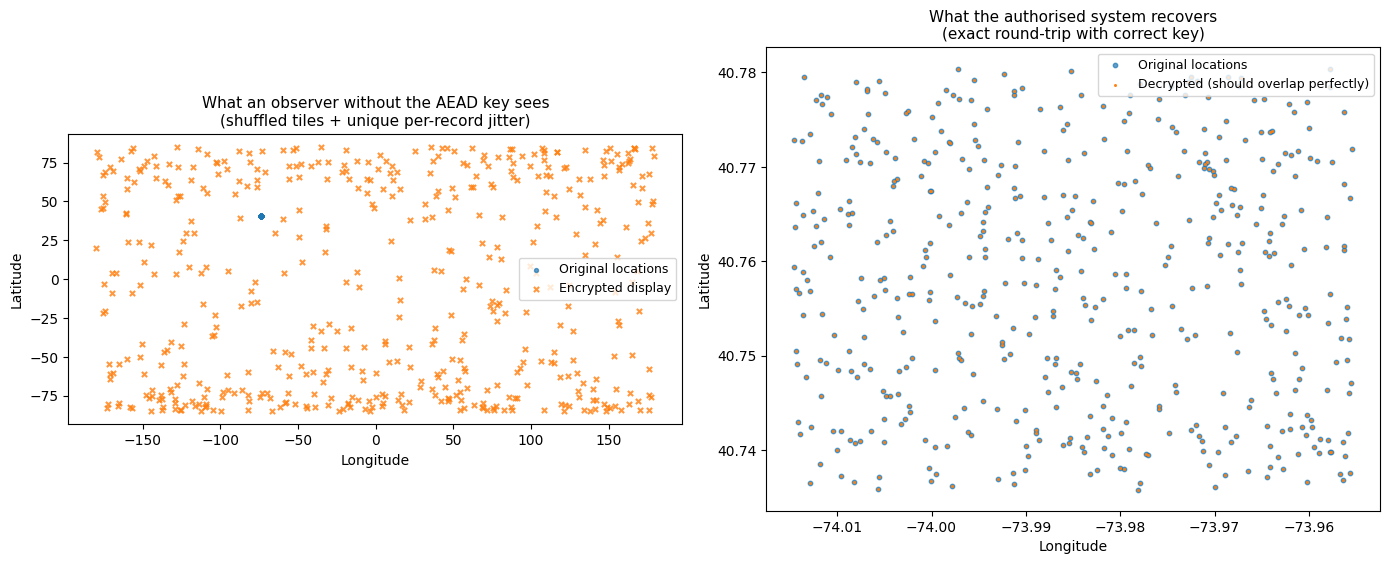

In [7]:
# In production: load MASTER_KEY from a secrets manager.
# Never store it in code, version control, or plaintext config files.
MASTER_KEY = secrets.token_bytes(32)
params     = SchemeParams(bin_size_m=250, jitter_max_frac=0.25, prp_rounds=10)
keys       = derive_keys(MASTER_KEY)

print(f'Scheme version : {SCHEME_VERSION}')
print(f'Bin size       : {params.bin_size_m} m per tile')
print(f'Jitter range   : +- {params.bin_size_m * params.jitter_max_frac:.0f} m')
print(f'PRP rounds     : {params.prp_rounds}')
print()


# Helper: convert a distance in metres to approximate degree offsets at a given latitude.
def metres_to_deg(dm_m: float, at_lat: float) -> Tuple[float, float]:
    dlat = math.degrees(dm_m / R_EARTH)
    dlon = math.degrees(dm_m / (R_EARTH * math.cos(math.radians(at_lat))))
    return dlat, dlon


# Generate synthetic GPS points in a 2.5 km radius around Times Square.
CENTER_LAT, CENTER_LON = 40.758, -73.985
NUM_POINTS  = 500
SPREAD_M    = 2500

lat_span, lon_span = metres_to_deg(SPREAD_M, CENTER_LAT)
rng       = np.random.default_rng(42)
orig_lats = CENTER_LAT + (rng.random(NUM_POINTS) - 0.5) * 2 * lat_span
orig_lons = CENTER_LON + (rng.random(NUM_POINTS) - 0.5) * 2 * lon_span
print(f'Generated {NUM_POINTS} synthetic points around Times Square.')


# Encode all points. Bind each to its array index via the tweak.
records  = []
enc_lats = []
enc_lons = []

for i, (lat, lon) in enumerate(zip(orig_lats, orig_lons)):
    tweak = make_tweak(record_id=i, extra=b'nyc-demo-v1')
    rec   = encode_point(float(lat), float(lon), params, keys, tweak=tweak)
    records.append(rec)
    elat, elon = encrypted_render_coordinates(rec, params, keys)
    enc_lats.append(elat)
    enc_lons.append(elon)

print(f'Encoded {NUM_POINTS} points.')


# Decode and verify exact round-trip for every record.
dec_lats = []
dec_lons = []
all_ok   = True

for i, (rec, o_lat, o_lon) in enumerate(zip(records, orig_lats, orig_lons)):
    result = decode_point(rec, params, keys)
    if result is None:
        print(f'ERROR: decryption failed for record {i}')
        all_ok = False
        break
    dlat, dlon = result
    dec_lats.append(dlat)
    dec_lons.append(dlon)
    if abs(dlat - o_lat) > 1e-9 or abs(dlon - o_lon) > 1e-9:
        print(f'ERROR: round-trip mismatch at record {i}')
        all_ok = False

print(f'Round-trip correct for all {NUM_POINTS} points: {all_ok}')


# Tamper detection: flip the first byte of one ciphertext.
tampered = dict(records[0])
tampered['ct_resid'] = bytes([tampered['ct_resid'][0] ^ 0xFF]) + tampered['ct_resid'][1:]
assert decode_point(tampered, params, keys) is None
print('Tamper detection:   OK  (1-bit flip correctly rejected)')


# Wrong-key rejection.
wrong_keys = derive_keys(secrets.token_bytes(32))
assert decode_point(records[0], params, wrong_keys) is None
print('Wrong-key rejection: OK  (different master key correctly rejected)')
print()


# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(orig_lons, orig_lats, s=8,  alpha=0.7, label='Original locations')
ax.scatter(enc_lons,  enc_lats,  s=14, alpha=0.8, marker='x', color='tab:orange',
           label='Encrypted display')
ax.set_title('What an observer without the AEAD key sees\n'
             '(shuffled tiles + unique per-record jitter)', fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=9)
ax.set_aspect('equal')

ax = axes[1]
ax.scatter(orig_lons, orig_lats, s=10, alpha=0.7, label='Original locations')
ax.scatter(dec_lons,  dec_lats,  s=6,  alpha=0.9, marker='.', color='tab:orange',
           label='Decrypted (should overlap perfectly)')
ax.set_title('What the authorised system recovers\n'
             '(exact round-trip with correct key)', fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=9)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---

## Section 7 — Tamper Detection and Failure Modes

The demo above already performed two quick sanity checks. This section makes the security property explicit: decryption should either return the **exact original point** or fail closed with `None`.

We test several failure modes that matter in practice:

- **Bit-flipping** in the ciphertext
- **Nonce tampering**
- **Shuffled-cell tampering** (`qxp`, `qyp`)
- **Record-binding failure** by changing the tweak that encodes the record identity
- **Scheme-version mismatch**
- **Wrong master key**

In the v3 notebook, record binding lives inside the `tweak`, so a record-substitution attack is modelled by swapping that tweak to one built for a different record ID.

In [8]:
# =============================================================================
# Section 7 — Tamper-detection tests
# =============================================================================

rec0 = records[0]
print('=== Section 7 — Tamper-detection tests ===')

# 1. Correct decryption must succeed.
result = decode_point(rec0, params, keys)
assert result is not None
print('Correct keys:                  OK — decrypted')

# 2. Flip one bit in the ciphertext.
tampered = dict(rec0)
ct = bytearray(rec0['ct_resid'])
ct[0] ^= 0x01
tampered['ct_resid'] = bytes(ct)
assert decode_point(tampered, params, keys) is None
print('Bit-flipped ciphertext:        CORRECTLY rejected')

# 3. Change one byte of the nonce.
tampered = dict(rec0)
nonce = bytearray(rec0['nonce'])
nonce[-1] ^= 0x01
tampered['nonce'] = bytes(nonce)
assert decode_point(tampered, params, keys) is None
print('Wrong nonce:                  CORRECTLY rejected')

# 4. Tamper with the shuffled grid cell.
tampered = dict(rec0)
tampered['qxp'] = tampered['qxp'] + 1
assert decode_point(tampered, params, keys) is None
print('Tampered shuffled cell:       CORRECTLY rejected')

# 5. Wrong record binding: tweak encodes the wrong record_id.
#    In the demo, record 0 used record_id=0 and extra=b'nyc-demo-v1'.
tampered = dict(rec0)
tampered['tweak'] = make_tweak(record_id=1, extra=b'nyc-demo-v1')
assert decode_point(tampered, params, keys) is None
print('Wrong record-binding tweak:   CORRECTLY rejected')

# 6. Wrong scheme version.
tampered = dict(rec0)
tampered['version'] = SCHEME_VERSION + 1
assert decode_point(tampered, params, keys) is None
print('Wrong scheme version:         CORRECTLY rejected')

# 7. Different master key (simulates key compromise / key mismatch).
wrong_keys = derive_keys(secrets.token_bytes(32))
assert decode_point(rec0, params, wrong_keys) is None
print('Wrong master key:             CORRECTLY rejected')

=== Section 7 — Tamper-detection tests ===
Correct keys:                  OK — decrypted
Bit-flipped ciphertext:        CORRECTLY rejected
Wrong nonce:                  CORRECTLY rejected
Tampered shuffled cell:       CORRECTLY rejected
Wrong record-binding tweak:   CORRECTLY rejected
Wrong scheme version:         CORRECTLY rejected
Wrong master key:             CORRECTLY rejected


---

## Section 8 — Known Limitations and Further Reading

### What this notebook does **not** solve by itself

**Custom-construction risk**: this notebook is an educational design built from standard primitives, but the overall scheme is still bespoke. For high-assurance production use, prefer a design with external cryptographic review, standardised components, published test vectors, and operational hardening.

**No formal anonymity guarantee**: the scheme protects precise coordinates from parties that do not have the decryption keys. It does **not** provide differential privacy, k-anonymity, or legal/policy guarantees by itself. If you publish aggregates or allow repeated spatial queries, distributional information can still leak.

**Access-pattern leakage**: encrypting stored coordinates does not hide *which* records are fetched, how often they are queried, or what time windows are being analysed. A powerful observer may still learn something from those side channels.

**Projection distortion**: Web Mercator is practical and invertible, but it stretches ground distances at high latitudes. For deployments concentrated far from the equator, a local projection (for example UTM or a national grid) gives more uniform bin sizes.

**Key compromise remains catastrophic**: anyone who obtains the relevant master key can derive the subkeys and recover exact locations. Production systems therefore need key rotation, audit logging, least-privilege access, and preferably KMS/HSM-backed key custody.

### Directions for improvement

- **Standardised format-preserving encryption**: replace the custom grid PRP with a reviewed construction such as **FF3-1** where appropriate.
- **Stronger operational key management**: store master keys in a KMS/HSM and use explicit rotation/version migration procedures.
- **Formal privacy layers**: add differential privacy, aggregation thresholds, or k-anonymity if the goal is safe data release rather than reversible storage protection.
- **Projection per region**: switch from global Web Mercator to a local projected CRS for better metric fidelity.
- **Structured record schemas**: formalise the on-disk record format and authenticate all security-relevant metadata consistently.

### References

- Luby & Rackoff (1988) — Feistel-network foundations for pseudorandom permutations.
- NIST SP 800-38G Rev. 1 — format-preserving encryption, including FF3-1.
- RFC 7539 — ChaCha20-Poly1305.
- RFC 5869 — HKDF.
- EPSG:3857 / Web Mercator documentation for projection behaviour and limits.